# Analyse data from metabolic cages

In [1]:
from tkinter.filedialog import askopenfilename
from tkinter import Tk
import pandas as pd
from datetime import datetime
from datetime import timedelta
import matplotlib.pyplot as plt
import math
import seaborn as sns
import numpy as np
from scipy.stats import ttest_ind
from sklearn import linear_model
from sklearn.metrics import mean_squared_error, r2_score
import copy
import pingouin as pg

color_list = ['#606060', '#76069A']

In [2]:
# Get the CalR file
# Open a dialog box to select the file to be analyzed
data = pd.read_csv("2023-11-20_CalR_000152.csv", index_col=0)

Cage labels in this dataset are different from mouse labels. Define the mapping between the two sets.

Also, define which mice are in which condition, and which mice are male/female.

Lastly, 3 mice should be removed from the fasting condition due to caching and hopper malfunction.

In [3]:
# Define subject mapping
subj_mapping = {17: 'A8539', 18: 'A8545', 19: 'A8532', 20: 'A8531',
                21: 'A8454', 22: 'A8538', 23: 'A8479', 24: 'A8446',
                25: 'A8478', 26: 'A8536', 27: 'A8544', 28: 'A8465',
                29: 'A8480', 30: 'A8481', 31: 'A8477', 32: 'A8455'}

condition_mapping = {'GFP': ['A8455', 'A8465', 'A8478', 'A8479',
                             'A8538', 'A8480', 'A8532', 'A8545'],
                     'TeNT': ['A8477', 'A8544', 'A8446', 'A8454',
                              'A8531', 'A8536', 'A8539', 'A8481']}

sex_mapping = {'Female': ['A8481', 'A8480'],
               'Male': ['A8539', 'A8545', 'A8532', 'A8531',
                        'A8454', 'A8538', 'A8479', 'A8446',
                        'A8478', 'A8536', 'A8544', 'A8465',
                        'A8477', 'A8455']}

remove_from_fasting = ['A8539', 'A8532', 'A8481']

condition_mapping_males = {}
condition_mapping_females = {}
for key in condition_mapping.keys():
    condition_mapping_males[key] = [i for i in condition_mapping[key] if i in sex_mapping['Male']]
    condition_mapping_females[key] = [i for i in condition_mapping[key] if i in sex_mapping['Female']]

Define the baseline and fasting periods.

In [4]:
baseline_period = pd.date_range(
    start=datetime(2023,11,7,6,0),
    end=datetime(2023,11,9,6,0),
    freq=timedelta(minutes=3)).tolist()

Change data format: dictionary, where every key is a different variable, and each key contains a dataframe, where rows = timepoints, and columns = mice.

In [5]:
data_dict = {}
datetime_range = data['Date.Time'].iloc[:sum(data['cage'] == data.at[1,'cage'])]
datetime_range = [datetime.strptime(dt, '%Y-%m-%d %H:%M:%S') for dt in list(datetime_range)]

for col in ['vo2', 'vco2', 'ee', 'ee.acc', 'rer', 'feed', 'feed.acc',
            'drink', 'drink.acc', 'xytot', 'xyamb', 'wheel',
            'wheel.acc', 'pedmeter', 'allmeter', 'body.temp']:
    data_dict[col] = pd.DataFrame()
    for mouse in data['cage'].unique():
        this_mouse = data[data['cage'] == mouse][col]
        this_mouse.name = subj_mapping[mouse]
        this_mouse.index = datetime_range
        data_dict[col] = pd.concat([data_dict[col],
                                    this_mouse], axis=1)

Check which variables were recorded

In [6]:
for var in data_dict.keys():
    print(f"Non-null entries in {var} - {data_dict[var].notnull().sum().sum()}")

Non-null entries in vo2 - 52704
Non-null entries in vco2 - 52704
Non-null entries in ee - 52704
Non-null entries in ee.acc - 52704
Non-null entries in rer - 52704
Non-null entries in feed - 52704
Non-null entries in feed.acc - 52704
Non-null entries in drink - 52704
Non-null entries in drink.acc - 52704
Non-null entries in xytot - 52704
Non-null entries in xyamb - 0
Non-null entries in wheel - 0
Non-null entries in wheel.acc - 0
Non-null entries in pedmeter - 52704
Non-null entries in allmeter - 52704
Non-null entries in body.temp - 0


In [7]:
# Drop non-recorded variables
rem_list = []
for var in data_dict.keys():
    if data_dict[var].notnull().sum().sum() == 0:
        rem_list.append(var)
_ = [data_dict.pop(var) for var in rem_list]

data_dict.keys()

dict_keys(['vo2', 'vco2', 'ee', 'ee.acc', 'rer', 'feed', 'feed.acc', 'drink', 'drink.acc', 'xytot', 'pedmeter', 'allmeter'])

In [8]:
##########################################
# Units of energy expenditure are kcal per time bin (3 mins). Convert to kcal/hr.
data_dict['ee'] = data_dict['ee']*20

In [9]:
# Define dark periods

dark_starts = [dt for dt in baseline_period if dt.hour == 18 and dt.minute == 0]
dark_ends = [dt for dt in baseline_period if dt.hour == 6 and dt.minute == 0]
if dark_ends[0] > dark_starts[0]:
    if len(dark_starts) > len(dark_ends):
        dark_starts = dark_starts[:-2]
else:
    dark_starts.insert(0, baseline_period[0])
dark_periods = pd.DataFrame({'starts': dark_starts, 'ends': dark_ends})
dark_periods

,starts,ends
0,2023-11-07 06:00:00,2023-11-07 06:00:00
1,2023-11-07 18:00:00,2023-11-08 06:00:00
2,2023-11-08 18:00:00,2023-11-09 06:00:00


In [10]:
# Function to plot rolling average for given variable in given period

def plot_rolling_mean(var, dic, wind, ax, period=baseline_period, cum=False, dark_periods=dark_periods, cm=condition_mapping):
    for i, cond in enumerate(cm.keys()):
        # For non-cumulative variables, taking rolling mean
        if cum == False:
            rolling_mean = dic[var][list(np.intersect1d(
                cm[cond], dic[var].columns))].loc[period].rolling(window=wind).mean()
        # For cumulative variables, calculate relative to t=0
        else:
            this_cond = dic[var][list(np.intersect1d(
                cm[cond], dic[var].columns))].loc[period]
            rolling_mean = this_cond - this_cond.loc[period[0]]
        # Mean +- SEM over mice
        mean = rolling_mean.mean(axis=1)
        sem = rolling_mean.sem(axis=1)
        upper = mean + sem
        lower = mean - sem
        mean.plot(color=color_list[i], linewidth=3, ax=ax, label=cond)
        ax.fill_between(mean.index, upper, lower, color=color_list[i], alpha=0.2)
    ax.set(xlabel='Time', ylabel=var, title=var)
    ax.legend()
    ylim = ax.get_ylim()
    # Add shading during dark period
    for i, dark in dark_periods.iterrows():
        dark_time = period[
            period.index(dark['starts']):
            period.index(dark['ends'])
        ]
        ax.fill_between(dark_time, ylim[0], ylim[1], color='darkgray', alpha=0.2)
    ax.set_ylim(ylim)

## Figures S16C-F

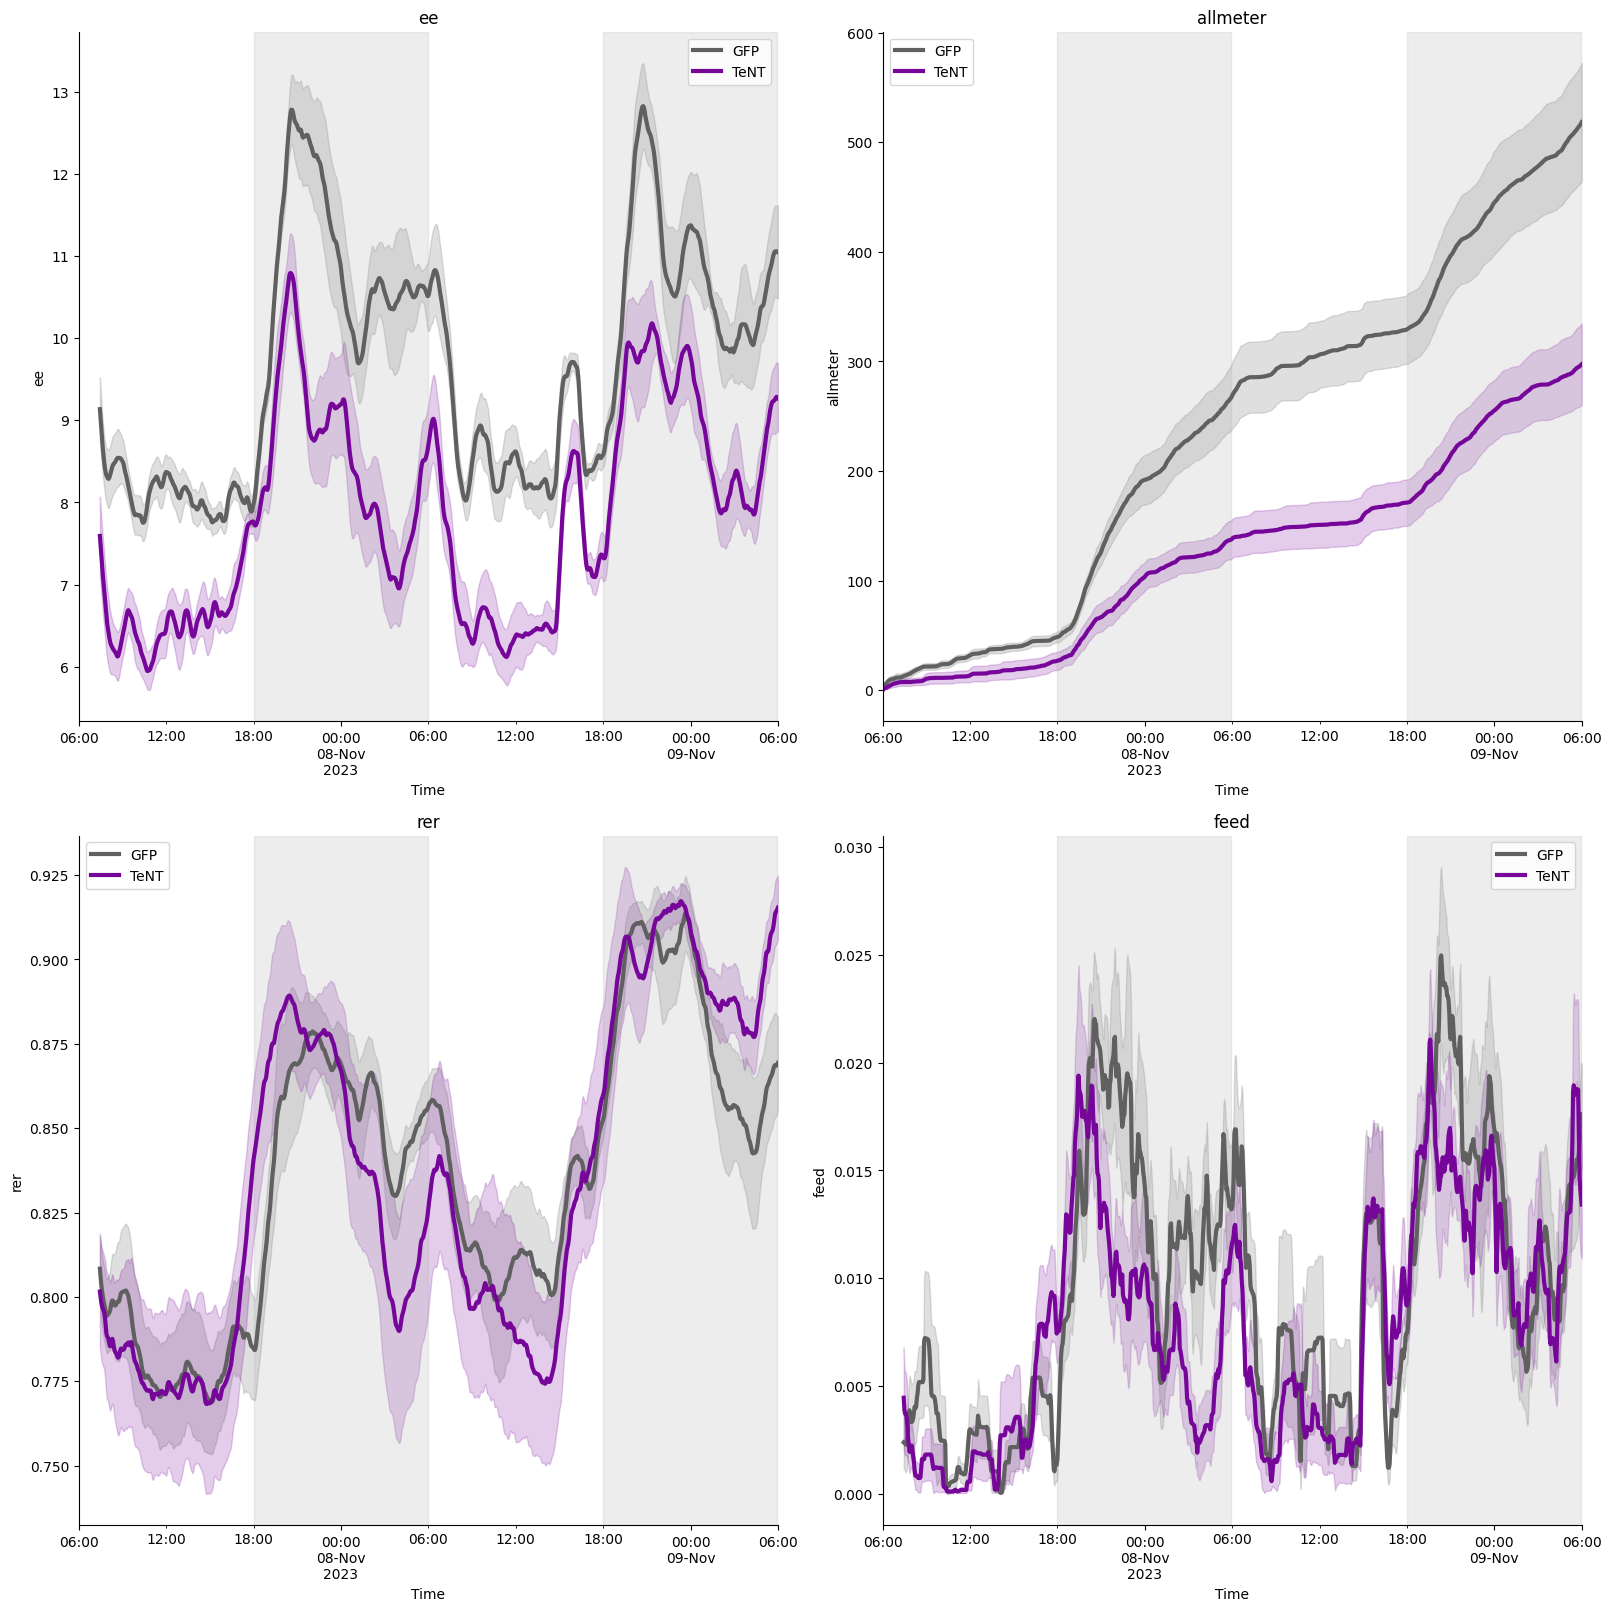

In [11]:
# Define which variables to plot
vars_to_plot = ['ee', 'allmeter', 'rer', 'feed']
# Define which variables are cumulative vs not
cum_vars = ['ee.acc', 'feed.acc', 'drink.acc', 'pedmeter', 'allmeter']
# Plot
fig, axs = plt.subplots(math.ceil(len(vars_to_plot)/2), 2,
                        figsize=(16,int(len(vars_to_plot)*8/2)),
                        layout='constrained')
for i, var in enumerate(vars_to_plot):
    if var in cum_vars:
        plot_rolling_mean(var, data_dict, 30, axs[(math.floor(i/2), i % 2)], baseline_period, cum=True, cm=condition_mapping_males)
    else:
        plot_rolling_mean(var, data_dict, 30, axs[(math.floor(i/2), i % 2)], baseline_period, cum=False, cm=condition_mapping_males)

for ax in axs.flatten():
    for loc in ['top','right']:
        ax.spines[loc].set_visible(False)

Now plot the average/total over the baseline period

In [12]:
# Functions to plot total/average for given variable in given period

# For cumulative variables: plot the average daily total over days in the period
def plot_total(var, dic, ax, period=baseline_period, cm=condition_mapping):
    cond_totals = pd.DataFrame()
    for cond in cm.keys():
        each_day = pd.DataFrame()
        # For each day in the period
        for day in range((period[-1] - period[0]).days):
            day_frame = period[
                period.index(period[0] + timedelta(days=day)):
                period.index(period[0] + timedelta(days=day+1))]
            this_day = dic[var][list(np.intersect1d(
                cm[cond], dic[var].columns))].loc[day_frame]
            each_day[day] = this_day.iloc[-1] - this_day.iloc[0]
        # For each mouse, take average over days
        this_cond = pd.DataFrame({
            'cond': [cond]*len(each_day),
            var: each_day.mean(axis=1)
        })
        cond_totals = pd.concat([cond_totals, this_cond])
    sns.boxplot(data=cond_totals, x='cond', y=var, ax=ax, hue='cond', palette=color_list, boxprops={'alpha': 0.4})
    sns.stripplot(data=cond_totals, x='cond', y=var, ax=ax, hue='cond', palette=color_list, dodge=True)
    ax.set(xlabel='Condition', ylabel=var + ' average daily total', title='Average daily ' + var)
    for loc in ['top','right']:
        ax.spines[loc].set_visible(False)
    return cond_totals

# For non-cumulative variables: plot the average value over the period
def plot_average(var, dic, ax, period=baseline_period, cm=condition_mapping):
    cond_means = pd.DataFrame()
    for cond in cm.keys():
        this_cond = pd.DataFrame({
            'cond': [cond]*len(list(np.intersect1d(
                cm[cond], dic[var].columns))),
            var: dic[var][list(np.intersect1d(
                cm[cond], dic[var].columns))].loc[period].mean(axis=0)
        })
        cond_means = pd.concat([cond_means, this_cond])
    sns.boxplot(data=cond_means, x='cond', y=var, ax=ax, hue='cond', palette=color_list, boxprops={'alpha': 0.4})
    sns.stripplot(data=cond_means, x='cond', y=var, ax=ax, hue='cond', palette=color_list, dodge=True)
    ax.set(xlabel='Condition', ylabel=var + ' average per period', title='Average ' + var)
    for loc in ['top','right']:
        ax.spines[loc].set_visible(False)
    return cond_means

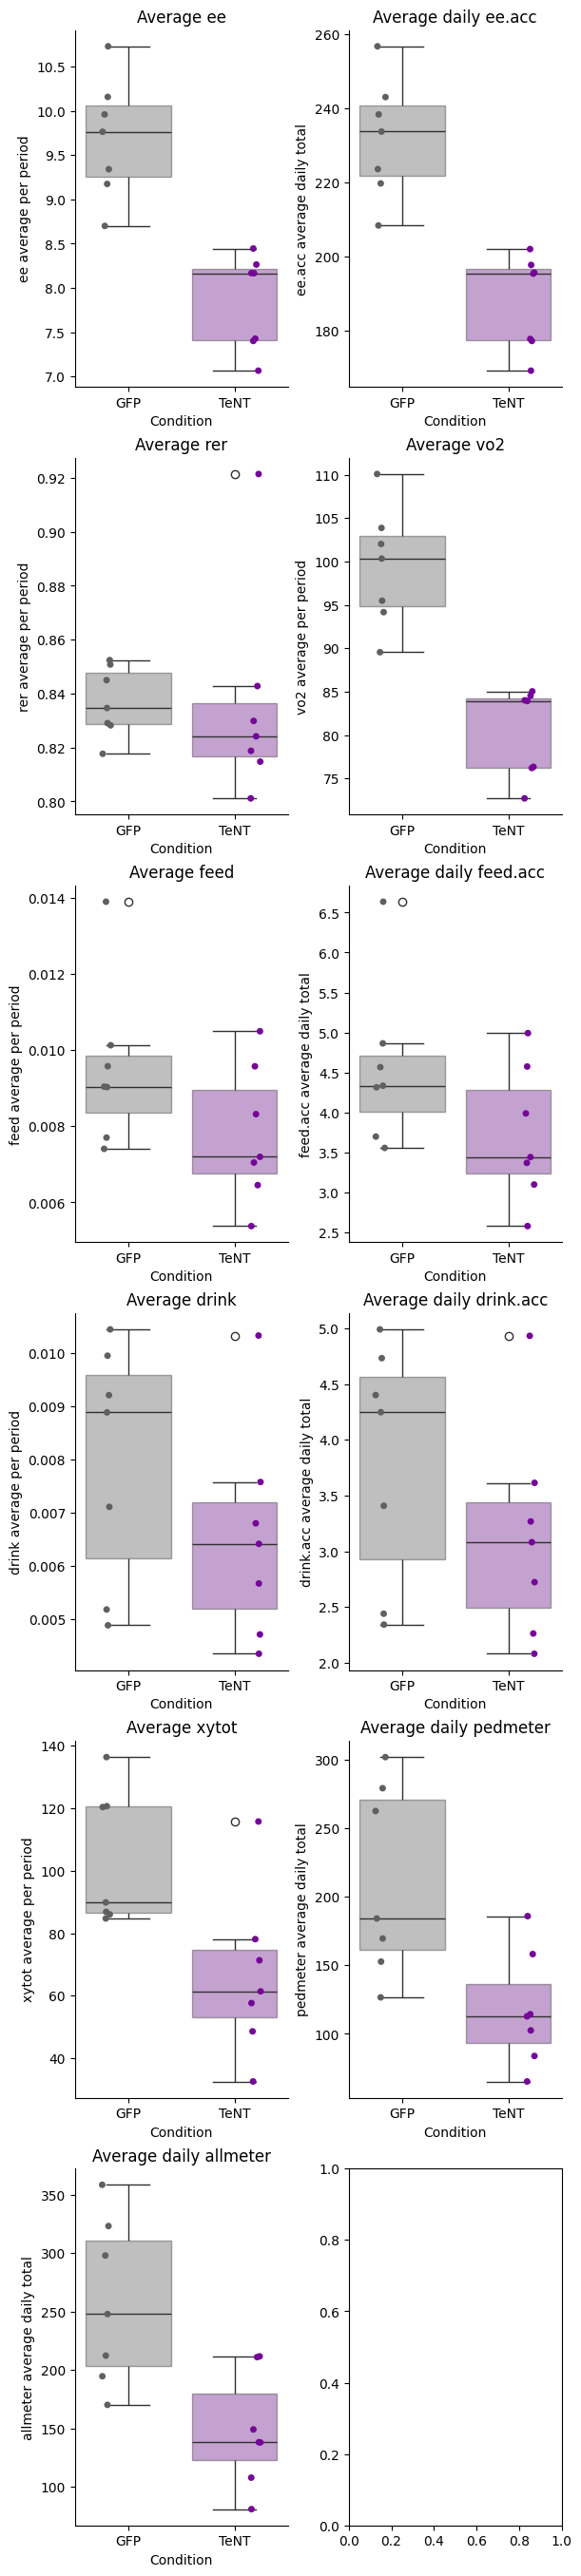

In [13]:
# Define which variables to plot
vars_to_plot = ['ee', 'ee.acc', 'rer', 'vo2', 'feed', 'feed.acc', 'drink', 'drink.acc', 'xytot', 'pedmeter', 'allmeter']
# Define which variables are cumulative vs not
cum_vars = ['ee.acc', 'feed.acc', 'drink.acc', 'pedmeter', 'allmeter']
# Plot, and store values
fig, axs = plt.subplots(math.ceil(len(vars_to_plot)/2), 2,
                        figsize=(6,int(len(vars_to_plot)*5/2)),
                        layout='constrained')
for i, var in enumerate(vars_to_plot):
    if var in cum_vars:
        cond_means = plot_total(var, data_dict, axs[(math.floor(i/2), i % 2)], baseline_period, cm=condition_mapping_males)
    else:
        cond_means = plot_average(var, data_dict, axs[(math.floor(i/2), i % 2)], baseline_period, cm=condition_mapping_males)
    if i == 0:
        mouse_means = cond_means
    else:
        mouse_means[var] = cond_means[var]

#fig.savefig('mouse_means_males.png')
#fig.savefig('mouse_means_males.pdf')

Statistical tests: use Welch's t-test to compare conditions for each variable.

In [14]:
for var in vars_to_plot:
    pval = ttest_ind(mouse_means[mouse_means['cond'] == 'GFP'][var],
                     mouse_means[mouse_means['cond'] == 'TeNT'][var],
                     equal_var=False).pvalue
    print(f"{var}: p = {pval}")

ee: p = 0.00013049793143461082
ee.acc: p = 0.00012489245043448527
rer: p = 0.9659741689002568
vo2: p = 0.0001041825579958632
feed: p = 0.12329931104579697
feed.acc: p = 0.11819597886924686
drink: p = 0.24391308025483047
drink.acc: p = 0.2519230842212393
xytot: p = 0.014228668552797415
pedmeter: p = 0.012090113842741335
allmeter: p = 0.006383389713718171


## Figure S16G

In [15]:
df = data_dict["feed"].copy()
df.index = pd.to_datetime(df.index)
df = df.loc[baseline_period].resample("H").sum()
df_meanoverdays = df.groupby(df.index.time).mean()
df_long = df_meanoverdays.reset_index().melt(id_vars="index", var_name="ID", value_name="value").rename(columns={"index": "time"})
id_to_condition = {
    id_: condition
    for condition, ids in condition_mapping.items()
    for id_ in ids
}
df_long['condition'] = df_long['ID'].map(id_to_condition)
rem = {
    17: "11-12",
    18: "12-13",
    19: "13-14",
    20: "14-15",
    21: "15-16",
    22: "16-17",
    23:  "17-18",
    0:  "18-19",
    1:  "19-20",
    2:  "20-21",
    3:  "21-22",
    4:  "22-23",
    5:  "23-0",
    6:  "0-1",
    7:  "1-2",
    8:  "2-3",
    9: "3-4",
    10: "4-5",
    11: "5-6",
    12: "6-7",
    13: "7-8",
    14: "8-9",
    15: "9-10",
    16: "10-11",
}

        Source     p-unc
0    condition  0.393184
1         time  0.000032
2  Interaction  0.042547


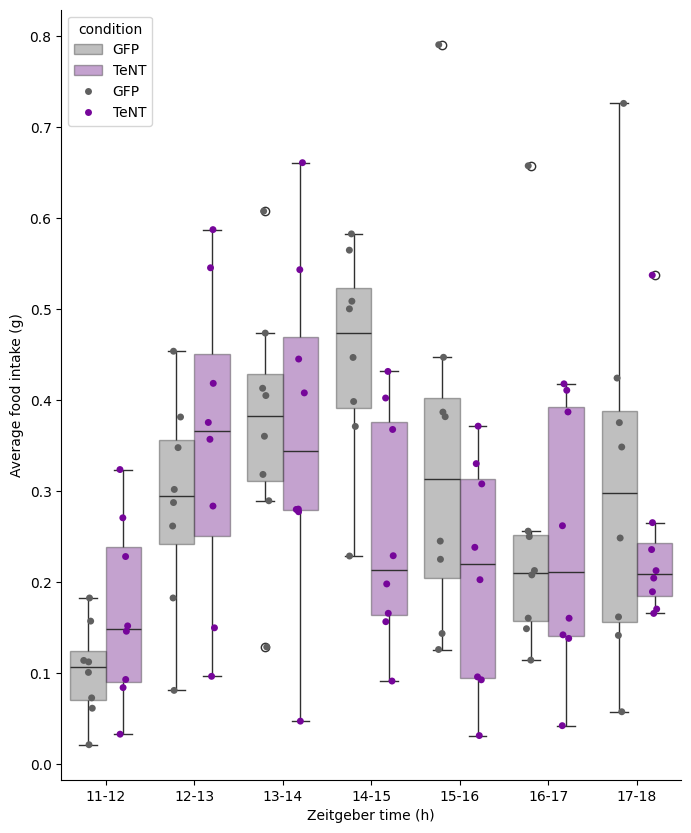

In [16]:
df_renamed = df_long.copy()
df_renamed["time"] = df_long["time"].apply(lambda t: rem[t.hour])
times_of_interest = [17, 18, 19, 20, 21, 22, 23]
times_of_interest = [rem[t] for t in times_of_interest]
df_sel = df_renamed[df_renamed["time"].isin(times_of_interest)]
fig, ax = plt.subplots(1,1, figsize=(8,10))
res = pg.mixed_anova(dv="value", within="time", between="condition", subject="ID", data=df_sel)
print(res[["Source", "p-unc"]])

sns.boxplot(
    data=df_sel,
    x='time',
    y='value',
    hue='condition',
    ax=ax,
    hue_order=["GFP", "TeNT"],
    palette=color_list,
    boxprops={'alpha': 0.4}
)
sns.stripplot(
    data=df_sel,
    x='time',
    y='value',
    hue='condition',
    ax=ax,
    hue_order=["GFP", "TeNT"],
    palette=color_list,
    dodge=True
)

ax.set(ylabel="Average food intake (g)", xlabel="Zeitgeber time (h)")
for loc in ['top','right']:
    ax.spines[loc].set_visible(False)


#fig.savefig('hourly_food_intake_males.png')
#fig.savefig('hourly_food_intake_males.pdf')


In [17]:
# Post-hoc t-tests comparing conditions at each time point
posthoc = pg.pairwise_tests(
    data=df_sel,
    dv="value",
    between="condition",
    within="time",
    subject="ID",
    padjust="none"
)
posthoc_cond = posthoc[posthoc['Contrast'] == 'time * condition'].copy()
posthoc_cond['p-corr'] = pg.multicomp(
    posthoc_cond['p-unc'].values,
    method='holm'
)[1]
posthoc_cond[["time", "p-unc", "p-corr"]]

,time,p-unc,p-corr
22,11-12,0.133118,0.798706
23,12-13,0.395624,1.000000
24,13-14,0.936435,1.000000
25,14-15,0.006500,0.045502
26,15-16,0.149229,0.798706
27,16-17,0.941889,1.000000
28,17-18,0.476898,1.000000


## Correlation between variables
## Figure 6F

Now plot energy expenditure vs total mass, colored by group.

In [18]:
# Get body weight data
bw_data = pd.read_csv("2023-11-20_Session_baseline_23C.csv", index_col=0)
bw_data = bw_data[['Total.Mass', 'Lean.Mass', 'Fat.Mass', 'id']]
bw_data.dropna(inplace=True)
# Get true IDs
bw_data.index = bw_data['id'].replace(subj_mapping)

# Merge onto metabolic data
mouse_means = mouse_means.merge(bw_data, how='outer', left_index=True, right_index=True)
mouse_means.sort_values(by='cond', inplace=True)
mouse_means = mouse_means.dropna()


Linear regression parameters for GFP:
Coefficient: -0.01
Intercept: 9.9
Mean squared error: 0.3855865817102197
R^2: 0.00104500810872854

Linear regression parameters for TeNT:
Coefficient: -0.16
Intercept: 11.99
Mean squared error: 0.18384910002868635
R^2: 0.2434406900208369


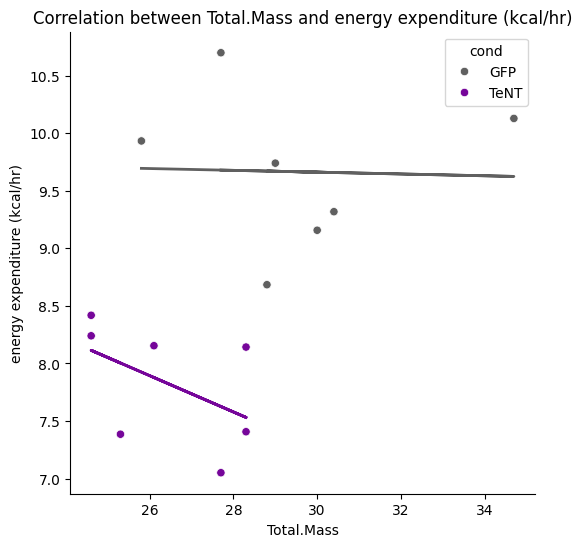

In [19]:
# Plot correlation between two variables of interest for each group
fig, ax = plt.subplots(1,1, figsize=(6,6))

def plot_correlation_separate_conds(df, x_var, y_var, ax=ax):
    # Plot actual values
    _ = sns.scatterplot(data=df, x=x_var, y=y_var,
                        hue='cond', palette=color_list,
                        ax=ax)

    # Fit linear regression for each condition, and plot
    for i, cond in enumerate(mouse_means['cond'].unique()):
        # Create linear regression object
        regr = linear_model.LinearRegression()

        # Fit linear regression
        X = np.array(mouse_means[mouse_means['cond'] == cond][x_var]).reshape(-1, 1)
        Y = np.array(mouse_means[mouse_means['cond'] == cond][y_var]).reshape(-1, 1)
        regr.fit(X, Y)
        # Predict
        y_pred = regr.predict(X)
        # Coefficients
        print(f"\nLinear regression parameters for {cond}:")
        print(f"Coefficient: {round(regr.coef_[0][0], 2)}")
        print(f"Intercept: {round(regr.intercept_[0], 2)}")
        print(f"Mean squared error: {mean_squared_error(Y, y_pred)}")
        print(f"R^2: {r2_score(Y, y_pred)}")
        # Plot
        ax.plot(X, y_pred, color=color_list[i], linewidth=2)
    ax.set(title=f'Correlation between {x_var} and {y_var}',
           xlabel=x_var,
           ylabel=y_var)

mouse_means['energy expenditure (kcal/hr)'] = mouse_means['ee.acc'] / 24
plot_correlation_separate_conds(mouse_means, x_var='Total.Mass', y_var='energy expenditure (kcal/hr)', ax=ax)


for loc in ['top','right']:
    ax.spines[loc].set_visible(False)

#fig.savefig('Corr_mass_ee_males.png')
#fig.savefig('Corr_mass_ee_males.pdf')